In [3]:
#PCA 


In [4]:
# PCA (Analyse en composantes principales) est un algorithme de réduction de dimension qui transforme un grand ensemble de variables 
#en un nombre plus petit de composantes principales tout en conservant le maximum d’information possible, son objectif est de simplifier les données 
#et faciliter leur analyse et apprentissage.


DATASET ORIGINAL:
[[2.  2. ]
 [3.  3. ]
 [4.  4. ]
 [5.  5. ]
 [1.  1. ]
 [3.5 3.2]
 [2.2 2.1]
 [1.5 1.4]
 [4.5 4.2]
 [5.2 5.1]]

MOYENNE DE CHAQUE FEATURE:
mean x1, x2 = [3.19 3.1 ]

DONNÉES APRÈS CENTRAGE:
[[-1.19 -1.1 ]
 [-0.19 -0.1 ]
 [ 0.81  0.9 ]
 [ 1.81  1.9 ]
 [-2.19 -2.1 ]
 [ 0.31  0.1 ]
 [-0.99 -1.  ]
 [-1.69 -1.7 ]
 [ 1.31  1.1 ]
 [ 2.01  2.  ]]

MATRICE DE COVARIANCE:
[[2.20766667 2.16111111]
 [2.16111111 2.12888889]]

VALEURS PROPRES (importance de chaque axe):
[4.32974781 0.00680774]

VECTEURS PROPRES (directions PCA):
[[ 0.71352057 -0.70063429]
 [ 0.70063429  0.71352057]]

APRÈS TRI:
Eigenvalues triées: [4.32974781 0.00680774]
Eigenvectors triés: [[ 0.71352057 -0.70063429]
 [ 0.70063429  0.71352057]]

PC1 (direction principale):
[[0.71352057]
 [0.70063429]]

DONNÉES APRÈS PCA (1D):
[[-1.61978719]
 [-0.20563234]
 [ 1.20852252]
 [ 2.62267737]
 [-3.03394204]
 [ 0.2912548 ]
 [-1.40701965]
 [-2.39692804]
 [ 1.70540966]
 [ 2.83544491]]


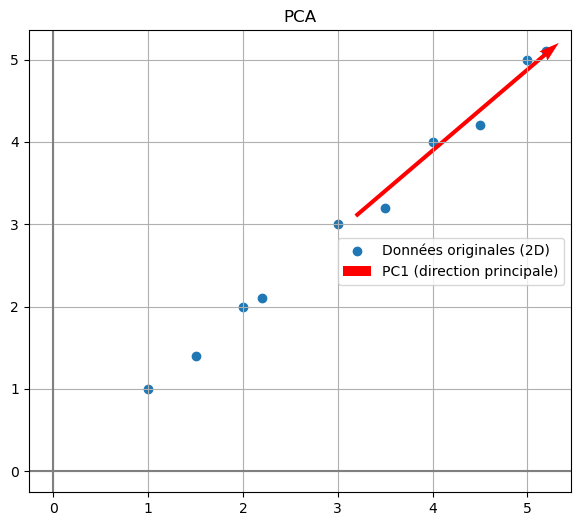

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ====================================
# 1. DATASET
# ====================================

# On crée un dataset 2D avec deux features :
# x1 et x2 représentent deux variables corrélées
# Exemple : taille et poids
X = np.array([
    [2, 2],
    [3, 3],
    [4, 4],
    [5, 5],
    [1, 1],
    [3.5, 3.2],
    [2.2, 2.1],
    [1.5, 1.4],
    [4.5, 4.2],
    [5.2, 5.1],
])

# Affichage des données originales
print("\nDATASET ORIGINAL:")
print(X)

# ====================================
# 2. CENTRAGE DES DONNÉES
# ====================================

# Pourquoi on centre ?
# PCA fonctionne mieux si les données sont centrées autour de 0

# On calcule la moyenne de chaque colonne (x1 et x2 séparément)
mean = np.mean(X, axis=0)

print("\nMOYENNE DE CHAQUE FEATURE:")
print("mean x1, x2 =", mean)

# On soustrait la moyenne à chaque point
# Cela déplace les données autour de l'origine (0,0)
X_centered = X - mean

print("\nDONNÉES APRÈS CENTRAGE:")
print(X_centered)

# ====================================
# 3. MATRICE DE COVARIANCE
# ====================================

# La covariance mesure :
# - si x1 et x2 varient ensemble
# - si la relation est forte ou faible

cov_matrix = np.cov(X_centered.T)

print("\nMATRICE DE COVARIANCE:")
print(cov_matrix)

# ====================================
# 4. VALEURS PROPRES ET VECTEURS PROPRES
# ====================================

# Eigenvalues = quantité d'information (variance) dans chaque direction
# Eigenvectors = directions principales des données

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("\nVALEURS PROPRES (importance de chaque axe):")
print(eigenvalues)

print("\nVECTEURS PROPRES (directions PCA):")
print(eigenvectors)

# ====================================
# 5. TRI DES COMPOSANTES
# ====================================

# On trie les valeurs propres du plus grand au plus petit
# Pourquoi ?
# Car PC1 = direction la plus importante (max variance)

idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("\nAPRÈS TRI:")
print("Eigenvalues triées:", eigenvalues)
print("Eigenvectors triés:", eigenvectors)

# ====================================
# 6. COMPOSANTE PRINCIPALE (PC1)
# ====================================

# On garde seulement la première direction principale
# PC1 contient la majorité de l'information

W = eigenvectors[:, :1]

print("\nPC1 (direction principale):")
print(W)

# ====================================
# 7. PROJECTION DES DONNÉES
# ====================================

# Ici on applique la formule PCA :
# on projette les données sur PC1

# Z = X_centered × W
# Résultat = données en 1 dimension

X_pca = np.dot(X_centered, W)

print("\nDONNÉES APRÈS PCA (1D):")
print(X_pca)

# ====================================
# 8. VISUALISATION
# ====================================

plt.figure(figsize=(7,6))

# Affichage des points originaux en 2D
plt.scatter(X[:,0], X[:,1], label="Données originales (2D)")

# Axes classiques x1 et x2
plt.axhline(0, color='gray')
plt.axvline(0, color='gray')

# Origine pour tracer PC1
origin = mean

# Direction de PC1 (multipliée pour mieux la voir)
pc1 = eigenvectors[:,0] * 3

# On trace la direction principale
plt.quiver(
    origin[0], origin[1],
    pc1[0], pc1[1],
    angles='xy',
    scale_units='xy',
    scale=1,
    color='red',
    label="PC1 (direction principale)"
)

# Titre du graphique
plt.title("PCA")
plt.grid()
plt.legend()
plt.show()